In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv("tanks_data.csv")

data['Type'] = data['Type'].replace({
    'Artillery': 'Group_1',
    'Tank Destroyer': 'Group_1',
    'Light Tank': 'Group_2',
    'Medium Tank': 'Group_2',
    'Heavy Tank': 'Group_2'
})

X = data.drop(columns=['Type', 'Name'])
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [2]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

score = log_model.score(X_test, y_test)
print(score)

0.964


In [2]:
from sklearn.model_selection import RandomizedSearchCV
from LinearRegressionClassifier import LinearClassifierGD
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer
import numpy as np

param_dist_linear = {
    'alpha': np.random.uniform(0.1, 1.0, 10),
    'lambda_': np.random.uniform(0.001, 0.1, 10),
    'learning_rate': np.random.uniform(0.001, 0.1, 10),
    'loss': ['logistic', 'squared', 'linear']
}

linear_model = LinearClassifierGD(max_iter=3000)
scorer = make_scorer(accuracy_score)

random_search_linear = RandomizedSearchCV(estimator=linear_model, param_distributions=param_dist_linear,
                                          n_iter=20, cv=3, scoring=scorer, verbose=1, random_state=42)
random_search_linear.fit(X_train, y_train)

print(f"Best Parameters: {random_search_linear.best_params_}")
print(f"Best Cross-validation Score: {random_search_linear.best_score_}")

#Best Parameters: {'loss': 'squared', 'learning_rate': np.float64(0.009973660315651944), 'lambda_': np.float64(0.01451552758559058), 'alpha': np.float64(0.4106826557795271)}
#Best Cross-validation Score: 0.9611780455153949

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'max_iter': np.int64(2000), 'loss': 'squared', 'learning_rate': np.float64(0.009973660315651944), 'lambda_': np.float64(0.01451552758559058), 'alpha': np.float64(0.4106826557795271)}
Best Cross-validation Score: 0.9611780455153949


In [7]:
from sklearn.model_selection import RandomizedSearchCV
from LinearRegressionClassifier import SVMClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import make_scorer

param_dist_svm = {
    'kernel': ['linear', 'polynomial', 'rbf'],
    'C': np.random.uniform(0.01, 10.0, 10),
    'learning_rate': np.random.uniform(0.0001, 0.1, 10),
    'degree': np.random.choice([2, 3, 4], 3),
    'gamma': np.random.uniform(0.0001, 1, 10), 
}


svm_model = SVMClassifier(max_iter=3000)

scorer = make_scorer(accuracy_score)

random_search_svm = RandomizedSearchCV(estimator=svm_model, param_distributions=param_dist_svm,
                                       n_iter=20, cv=3, scoring=scorer, verbose=1, random_state=42)
random_search_svm.fit(X_train, y_train)

print(f"Best Parameters: {random_search_svm.best_params_}")
print(f"Best Cross-validation Score: {random_search_svm.best_score_}")
#Best Parameters: {'learning_rate': np.float64(0.04399920151695282), 'kernel': 'linear', 'degree': np.int64(2), 'C': np.float64(0.47898401880733327)}
#Best Cross-validation Score: 0.971566265060241

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'learning_rate': np.float64(0.011765531352656304), 'kernel': 'polynomial', 'gamma': np.float64(0.4863065890467686), 'degree': np.int64(4), 'C': np.float64(1.7334247456780607)}
Best Cross-validation Score: 0.9477911646586344


In [2]:
from LinearRegressionClassifier import RidgeRegressionClassifier
from sklearn.metrics import accuracy_score

ridge_model = RidgeRegressionClassifier(alpha=0.001)
ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.984


In [2]:
from LinearRegressionClassifier import LinearClassifierGD
from sklearn.metrics import accuracy_score

linear_model = LinearClassifierGD(alpha=0, max_iter=3000, loss='squared')
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.952


In [3]:
from LinearRegressionClassifier import SVMClassifier
from sklearn.metrics import accuracy_score

svm_model = SVMClassifier(max_iter=3000, kernel='linear', learning_rate=0.00001)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

Сходимость достигнута на 2595 итерации
0.968


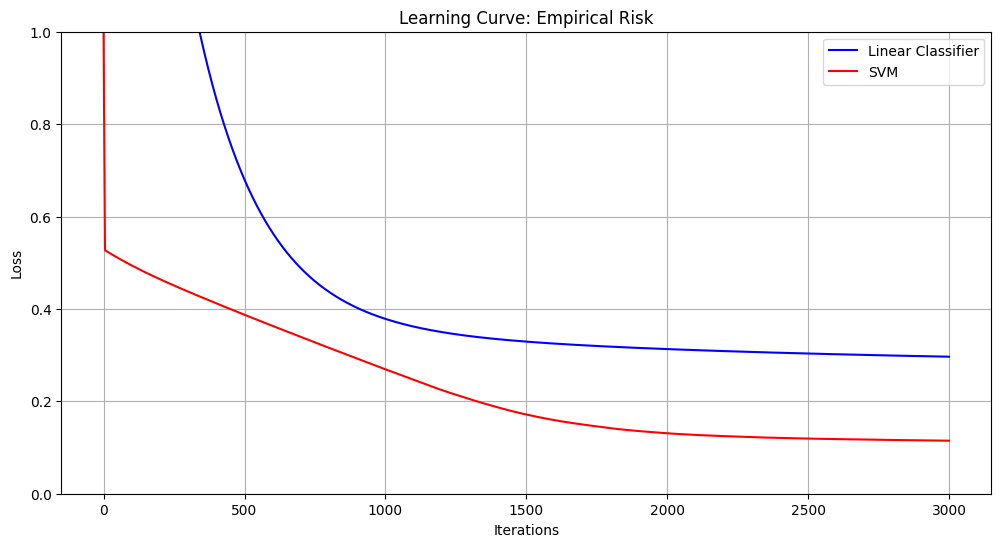

In [20]:
import matplotlib.pyplot as plt

linear_loss_history = linear_model.get_loss_history()
svm_loss_history = svm_model.get_loss_history()

plt.figure(figsize=(12, 6))
plt.ylim(0, 1)
plt.plot(linear_loss_history, label='Linear Classifier', color='blue')
plt.plot(svm_loss_history, label='SVM', color='red')
plt.title("Learning Curve: Empirical Risk")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Сходимость достигнута на 2519 итерации


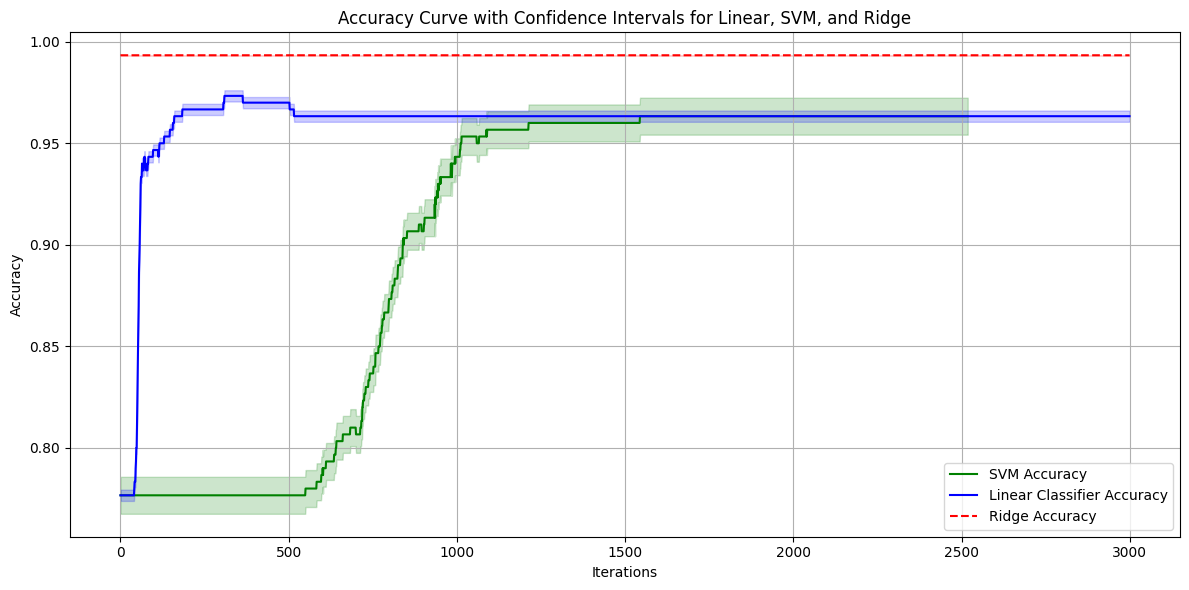

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from LinearRegressionClassifier import LinearClassifierGD, SVMClassifier, RidgeRegressionClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from scipy.stats import norm

def calculate_confidence_interval(mean, std, n, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)
    margin_of_error = z * (std / np.sqrt(n))
    return mean - margin_of_error, mean + margin_of_error


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

linear_model = LinearClassifierGD(alpha=0, max_iter=3000, loss='squared')
linear_model.fit(X_train, y_train, X_test, y_test)
linear_accuracy_history = linear_model.get_accuracy_history()

svm_model = SVMClassifier(max_iter=3000, kernel='linear', learning_rate=0.00001)
svm_model.fit(X_train, y_train, X_test, y_test)
svm_accuracy_history = svm_model.get_accuracy_history()

ridge_model = RidgeRegressionClassifier(alpha=0.001)
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
ridge_acc = accuracy_score(y_test, y_pred)

ridge_accuracy_history = np.full_like(linear_accuracy_history, ridge_acc, dtype=float)

n_test = len(y_test)

linear_mean = np.array(linear_accuracy_history)
svm_mean = np.array(svm_accuracy_history)
ridge_mean = np.array(ridge_accuracy_history)

linear_std = np.std(linear_accuracy_history)
svm_std = np.std(svm_accuracy_history)
ridge_std = np.std(ridge_accuracy_history)

linear_confidence_lower, linear_confidence_upper = calculate_confidence_interval(linear_mean, linear_std, n_test)
svm_confidence_lower, svm_confidence_upper = calculate_confidence_interval(svm_mean, svm_std, n_test)
ridge_confidence_lower, ridge_confidence_upper = calculate_confidence_interval(ridge_mean, ridge_std, n_test)

plt.figure(figsize=(12, 6))

plt.plot(svm_accuracy_history, label='SVM Accuracy', color='green')
plt.fill_between(range(len(svm_accuracy_history)), svm_confidence_lower, svm_confidence_upper, color='green', alpha=0.2)


plt.plot(linear_accuracy_history, label='Linear Classifier Accuracy', color='blue')
plt.fill_between(range(len(linear_accuracy_history)), linear_confidence_lower, linear_confidence_upper, color='blue', alpha=0.2)


plt.plot(ridge_accuracy_history, label='Ridge Accuracy', color='red', linestyle='--')
plt.fill_between(range(len(ridge_accuracy_history)), ridge_confidence_lower, ridge_confidence_upper, color='red', alpha=0.2)

plt.title("Accuracy Curve with Confidence Intervals for Linear, SVM, and Ridge")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
